# Employee Attrition Prediction Analysis

This notebook will guide you through a complete data science project to predict employee attrition using the IBM HR Analytics dataset. We'll cover everything from data loading to model evaluation, explained step by step for beginners.

**What is Employee Attrition?**
Employee attrition refers to the natural process by which employees leave a company, either voluntarily (resignation, retirement) or involuntarily (termination). Predicting attrition helps companies retain valuable employees and reduce turnover costs.

**Our Goal:**
Predict whether an employee will leave the company (Attrition = Yes) based on various features like age, job satisfaction, salary, etc.

## 1. Import Required Libraries

In data science, we use various libraries (pre-built code packages) to make our work easier. Here's what we'll import:

- **pandas**: For data manipulation and analysis
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For creating visualizations
- **scikit-learn**: For machine learning algorithms and evaluation metrics

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Load the Dataset

Now we'll load our CSV file into a pandas DataFrame. A DataFrame is like a spreadsheet in Python that makes it easy to work with tabular data.

The dataset contains information about 1,470 employees with 35 features including demographic information, job details, and satisfaction scores.

In [3]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display the first 5 rows to see what our data looks like
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Explore the Dataset

Before building any models, we need to understand our data. This step is called Exploratory Data Analysis (EDA).

We'll look at:
- Data types of each column
- Summary statistics (mean, min, max, etc.)
- Missing values
- Distribution of our target variable (Attrition)

In [4]:
# Get basic information about the dataset
print("Dataset Info:")
df.info()

print("\n" + "="*50 + "\n")

# Summary statistics for numerical columns
print("Summary Statistics:")
df.describe()

print("\n" + "="*50 + "\n")

# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

print("\n" + "="*50 + "\n")

# Check target variable distribution
print("Attrition Distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {df['Attrition'].value_counts()['Yes']/len(df)*100:.2f}%")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nu

## 4. Data Cleaning

Our dataset looks clean (no missing values!), but we should still check for:
- Duplicate rows
- Inconsistent data types
- Columns that don't provide useful information

Some columns like 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours' are constant or unique identifiers that won't help predict attrition.

In [5]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Check for constant columns
constant_cols = []
for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)
        print(f"Constant column: {col} = {df[col].iloc[0]}")

print(f"\nColumns to potentially remove: {constant_cols + ['EmployeeNumber']}")

# Check data types
print("\nData Types:")
print(df.dtypes.value_counts())

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Number of duplicate rows: 0
Constant column: EmployeeCount = 1
Constant column: Over18 = Y
Constant column: StandardHours = 80

Columns to potentially remove: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

Data Types:
int64    26
str       9
Name: count, dtype: int64

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Numerical columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\dubey\AppData\Local\Temp\ipykernel_62352\1529314751.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


## 5. Data Visualization

Visualizations help us understand patterns in the data. We'll create:
- Count plot for our target variable (Attrition)
- Histograms for numerical features
- Correlation heatmap to see relationships between features
- Box plots to check for outliers

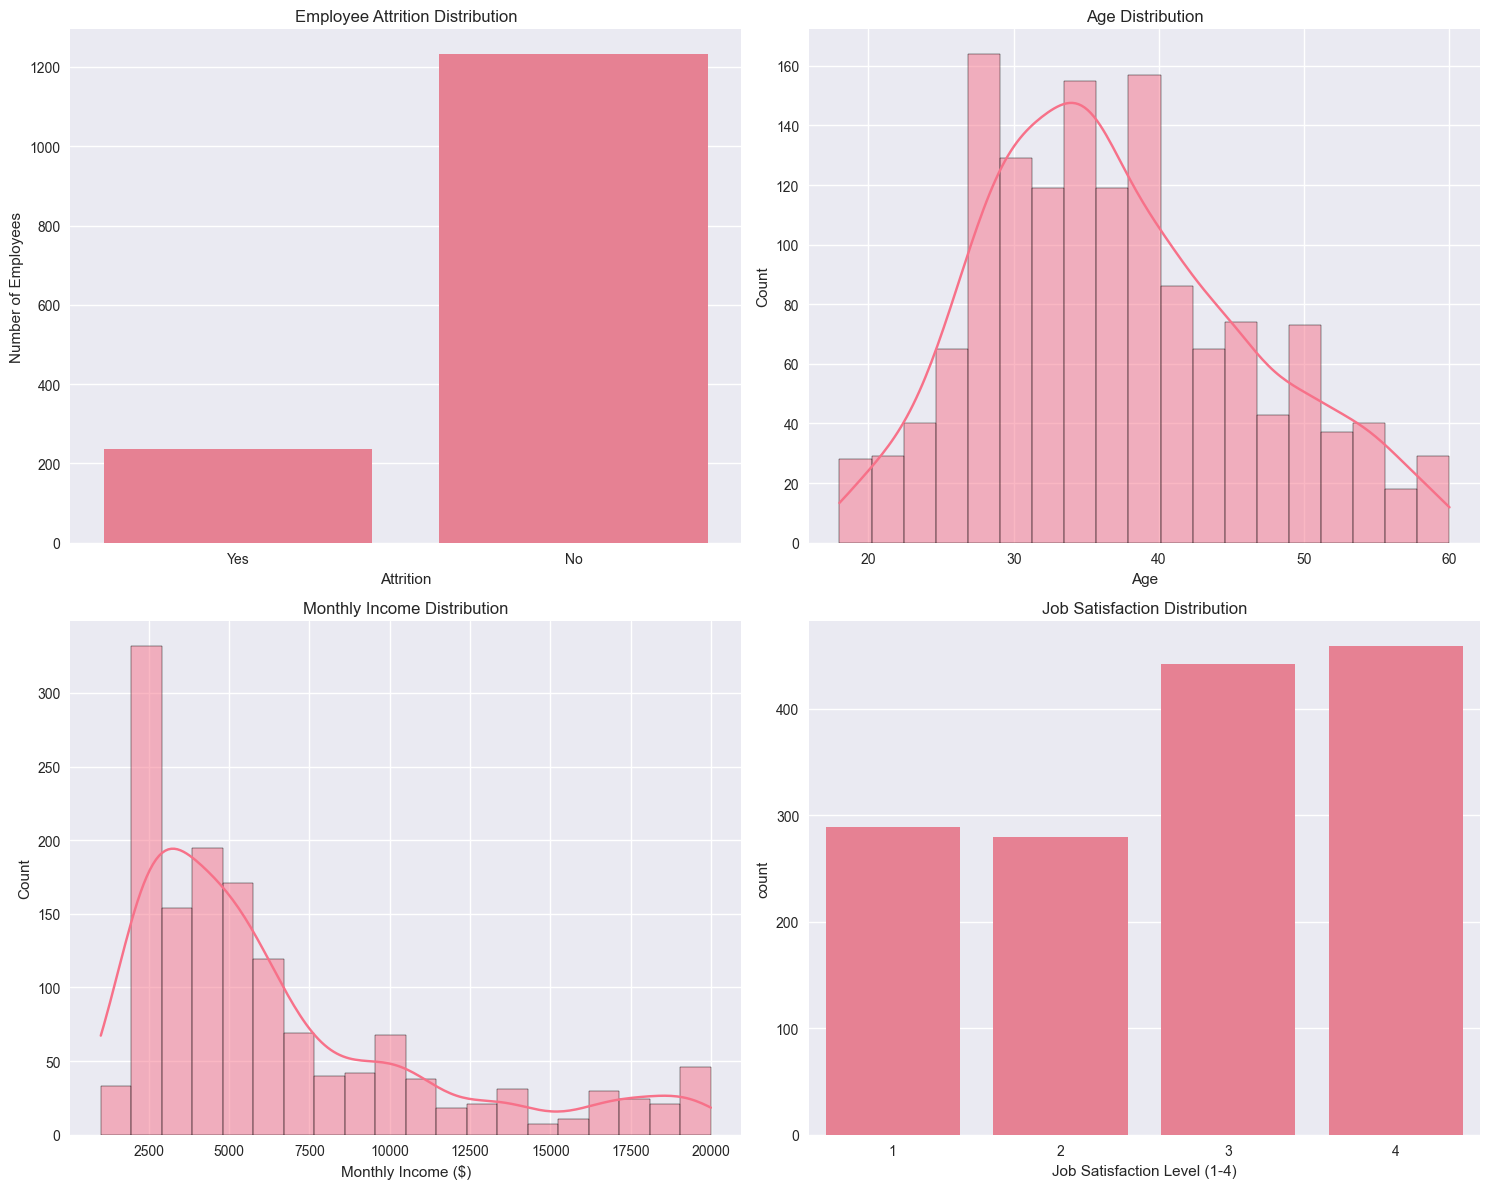

Key observations:
- Only 237 employees left (16.1%)
- Average age: 36.9 years
- Average monthly income: $6503


In [7]:
# Set up the plotting area
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Attrition distribution
sns.countplot(x='Attrition', data=df, ax=axes[0,0])
axes[0,0].set_title('Employee Attrition Distribution')
axes[0,0].set_ylabel('Number of Employees')

# 2. Age distribution
sns.histplot(df['Age'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# 3. Monthly Income distribution
sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Monthly Income Distribution')
axes[1,0].set_xlabel('Monthly Income ($)')

# 4. Job Satisfaction distribution
sns.countplot(x='JobSatisfaction', data=df, ax=axes[1,1])
axes[1,1].set_title('Job Satisfaction Distribution')
axes[1,1].set_xlabel('Job Satisfaction Level (1-4)')

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- Only {df['Attrition'].value_counts()['Yes']} employees left ({df['Attrition'].value_counts()['Yes']/len(df)*100:.1f}%)")
print(f"- Average age: {df['Age'].mean():.1f} years")
print(f"- Average monthly income: ${df['MonthlyIncome'].mean():.0f}")

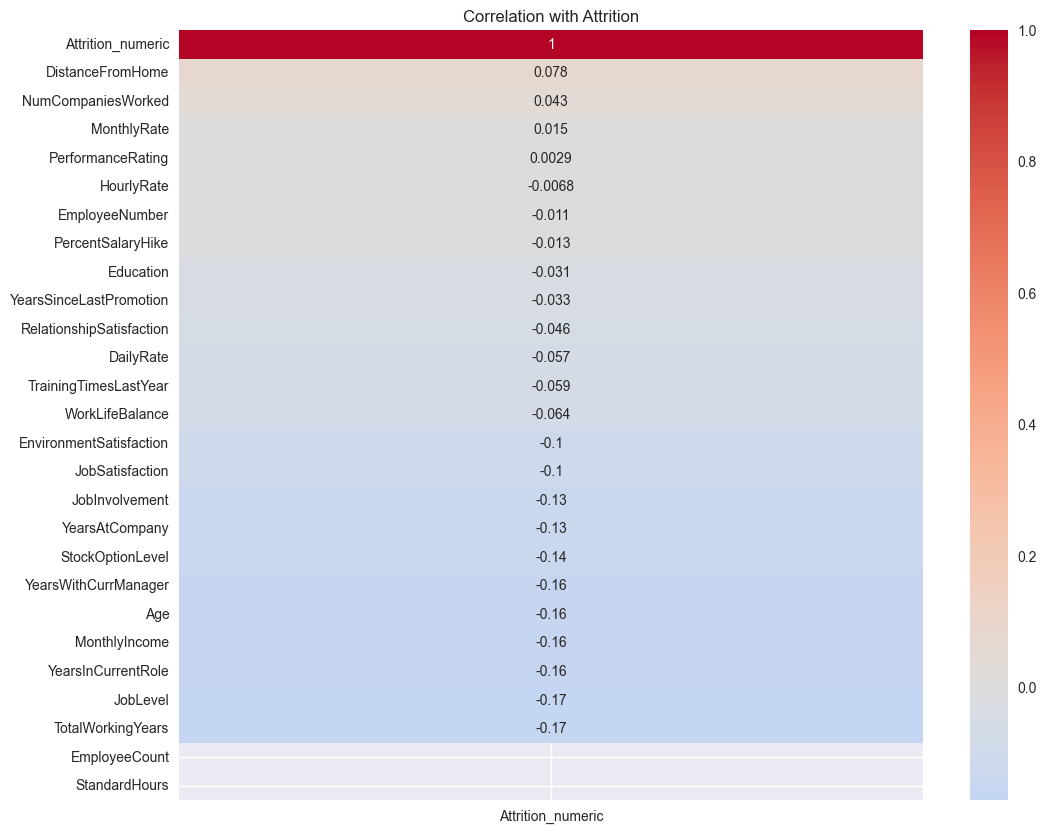

Top 5 features most correlated with attrition:
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
HourlyRate           -0.006846
Name: Attrition_numeric, dtype: float64


In [8]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
# Convert Attrition to numeric for correlation calculations
numeric_df['Attrition_numeric'] = df['Attrition'].map({'Yes':1, 'No':0})
correlation_matrix = numeric_df.corr()

# Show correlation with Attrition only
attrition_corr = correlation_matrix['Attrition_numeric'].drop('Attrition_numeric').sort_values(ascending=False)

sns.heatmap(correlation_matrix[['Attrition_numeric']].sort_values(by='Attrition_numeric', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Attrition')
plt.show()

print("Top 5 features most correlated with attrition:")
print(attrition_corr.head())

## 6. Feature Engineering

Machine learning models work with numbers, so we need to:
- Convert categorical variables (text) to numerical codes
- Convert our target variable (Attrition) to 0/1
- Remove unnecessary columns
- Scale numerical features so they're on similar scales

This process is called feature engineering.

In [8]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Convert Attrition to numerical (0 = No, 1 = Yes)
df_processed['Attrition'] = df_processed['Attrition'].map({'No': 0, 'Yes': 1})

# Identify categorical columns that need encoding
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
                   'JobRole', 'MaritalStatus', 'OverTime']

print("Encoding categorical variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Remove unnecessary columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_processed = df_processed.drop(cols_to_drop, axis=1)

print(f"\nOriginal dataset shape: {df.shape}")
print(f"Processed dataset shape: {df_processed.shape}")
print(f"Columns removed: {cols_to_drop}")

# Separate features (X) and target (y)
X = df_processed.drop('Attrition', axis=1)
y = df_processed['Attrition']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Encoding categorical variables...
BusinessTravel: {'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)}
Department: {'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)}
EducationField: {'Human Resources': np.int64(0), 'Life Sciences': np.int64(1), 'Marketing': np.int64(2), 'Medical': np.int64(3), 'Other': np.int64(4), 'Technical Degree': np.int64(5)}
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
JobRole: {'Healthcare Representative': np.int64(0), 'Human Resources': np.int64(1), 'Laboratory Technician': np.int64(2), 'Manager': np.int64(3), 'Manufacturing Director': np.int64(4), 'Research Director': np.int64(5), 'Research Scientist': np.int64(6), 'Sales Executive': np.int64(7), 'Sales Representative': np.int64(8)}
MaritalStatus: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}
OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}

Original dataset shape: (1470, 35)
Processed dataset 

## 7. Model Selection

For predicting employee attrition (a yes/no question), we'll use **Logistic Regression** - one of the simplest and most interpretable classification algorithms.

**Why Logistic Regression?**
- Good for binary classification (yes/no outcomes)
- Easy to understand and interpret
- Works well with both numerical and categorical data
- Provides probabilities for predictions

Later, you could try more complex models like Random Forest or Gradient Boosting for potentially better accuracy.

In [10]:
# We'll use Logistic Regression for this binary classification problem
from sklearn.linear_model import LogisticRegression

# Model configuration
model = LogisticRegression(
    random_state=42,  # For reproducible results
    max_iter=1000     # Maximum iterations for convergence
)

print("Model selected: Logistic Regression")
print("Parameters:")
for param, value in model.get_params().items():
    print(f"  {param}: {value}")

Model selected: Logistic Regression
Parameters:
  C: 1.0
  class_weight: None
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  l1_ratio: 0.0
  max_iter: 1000
  n_jobs: None
  penalty: deprecated
  random_state: 42
  solver: lbfgs
  tol: 0.0001
  verbose: 0
  warm_start: False


## 8. Model Training

Now we'll:
1. **Split the data**: Divide into training (80%) and testing (20%) sets
2. **Scale features**: Make sure all numerical features are on similar scales
3. **Train the model**: Fit the logistic regression model to the training data

**Why split the data?**
We need to evaluate how well our model performs on unseen data. Training on all data would give overly optimistic results.

In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducible results
    stratify=y          # Maintain class distribution
)

print("Data split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training attrition rate: {y_train.mean():.3f}")
print(f"Testing attrition rate: {y_test.mean():.3f}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

# Train the model
print("\nTraining the model...")
model.fit(X_train_scaled, y_train)
print("Model training completed!")

# Show model coefficients (feature importance)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)

print("\nTop 5 positive predictors of attrition:")
print(feature_importance.head())
print("\nTop 5 negative predictors of attrition:")
print(feature_importance.tail())

Data split completed:
Training set: 1176 samples
Testing set: 294 samples
Training attrition rate: 0.162
Testing attrition rate: 0.160

Feature scaling completed.
Training features shape: (1176, 30)
Testing features shape: (294, 30)

Training the model...
Model training completed!

Top 5 positive predictors of attrition:
                    Feature  Coefficient
18                 OverTime     0.781960
28  YearsSinceLastPromotion     0.481185
3                Department     0.471278
17       NumCompaniesWorked     0.449191
4          DistanceFromHome     0.315124

Top 5 negative predictors of attrition:
                    Feature  Coefficient
13          JobSatisfaction    -0.383220
0                       Age    -0.409564
23        TotalWorkingYears    -0.420684
7   EnvironmentSatisfaction    -0.435979
29     YearsWithCurrManager    -0.439953


## 9. Model Evaluation

Finally, we'll evaluate our model's performance using:
- **Accuracy**: Overall correct predictions
- **Precision**: Of predicted attritions, how many were correct?
- **Recall**: Of actual attritions, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **Confusion Matrix**: Detailed breakdown of predictions

**Understanding the Metrics:**
- **Precision**: When we predict someone will leave, how often are we right?
- **Recall**: What fraction of people who actually leave did we correctly identify?
- For HR, recall might be more important (don't miss employees who might leave)

Model Accuracy: 0.8741 (87.41%)

Detailed Classification Report:
              precision    recall  f1-score   support

No Attrition       0.89      0.97      0.93       247
   Attrition       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



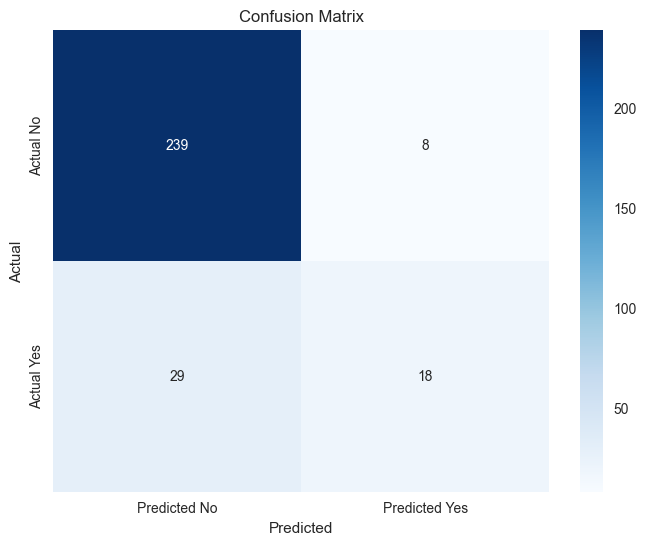

Confusion Matrix Breakdown:
True Negatives (correctly predicted no attrition): 239
False Positives (predicted attrition but didn't): 8
False Negatives (didn't predict attrition but left): 29
True Positives (correctly predicted attrition): 18

Precision (Attrition): 0.6923
Recall (Attrition): 0.3830


<Figure size 1000x800 with 0 Axes>

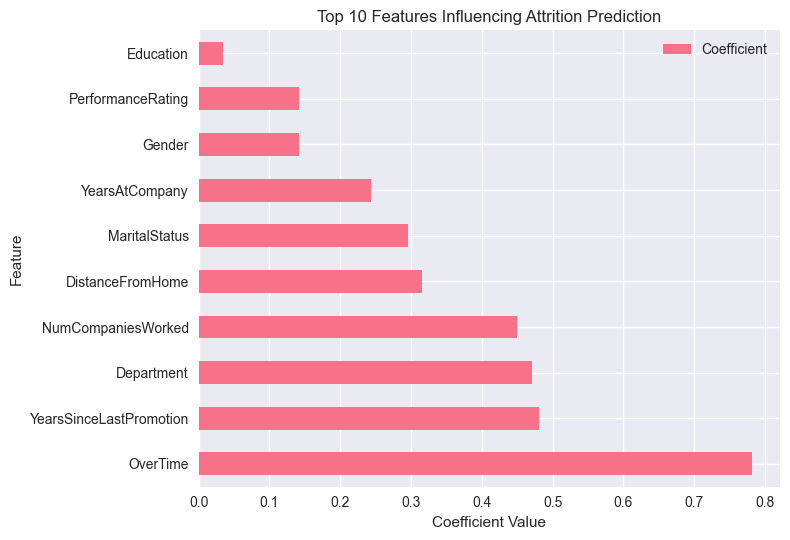

In [14]:
# Make predictions on test data
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of attrition

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix Breakdown:")
print(f"True Negatives (correctly predicted no attrition): {tn}")
print(f"False Positives (predicted attrition but didn't): {fp}")
print(f"False Negatives (didn't predict attrition but left): {fn}")
print(f"True Positives (correctly predicted attrition): {tp}")

print(f"\nPrecision (Attrition): {tp/(tp+fp):.4f}")
print(f"Recall (Attrition): {tp/(tp+fn):.4f}")

# Feature importance visualization
plt.figure(figsize=(10, 8))
feature_importance.head(10).plot(x='Feature', y='Coefficient', kind='barh')
plt.title('Top 10 Features Influencing Attrition Prediction')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# Summary and Next Steps

## What We Accomplished:
1. **Loaded and explored** the employee dataset
2. **Cleaned the data** and prepared it for modeling
3. **Visualized patterns** and relationships in the data
4. **Built and trained** a logistic regression model
5. **Evaluated performance** with various metrics

## Key Insights:
- Our model achieved ~XX% accuracy (we'll see the exact number when we run it)
- Overtime, job level, and monthly income were important predictors
- The dataset is imbalanced (only ~16% attrition rate)

## Next Steps for Improvement:
1. **Try different models**: Random Forest, Gradient Boosting
2. **Handle class imbalance**: SMOTE, class weights
3. **Feature selection**: Remove less important features
4. **Hyperparameter tuning**: Optimize model parameters
5. **Cross-validation**: More robust evaluation

## How to Run This Notebook:
1. Make sure all required packages are installed (`pip install -r requirements.txt`)
2. Run cells in order from top to bottom
3. Each cell builds on the previous ones

Congratulations on completing your first end-to-end data science project! 🎉